# Modeling 
1. Import libraries 
2. Load and split data (train and test)
3. Process data (train and test)
4. Fit model (train): .fit()
5. Model evaluation: CV RMSE, Train RMSE, MAE, Train R squared, Residuals, ...
6. Predict (test): .predict

## Import packages and pipeline

In [20]:
# import function built in pipeline
import sys
sys.path.append("../scripts")

import numpy as np

from preprocess import Pipeline, preprocess_data
from load_data import load_data, split_xy

# for modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# for visualization
import matplotlib.pyplot as plt

## Load & process Data

In [2]:
# Load train data and split
train_df = load_data("../data/train.csv")
train_X, train_y = split_xy(train_df)

In [3]:
# Load test data and split
test_df = load_data("../data/test.csv")
test_X = test_df.copy()

In [4]:
# Process data and check
train_X_processed, test_X_processed, pipeline = preprocess_data(train_X, test_X)

# Pipeline phải được fit 1 lần duy nhất trên train data, sau đó dùng cùng pipeline đó để transform test data
# Không gọi thành 2 lần khác nhau XXXX

## Fit model

In [5]:
# fit model
model = LinearRegression()
model.fit(train_X_processed, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Evaluate model

### MRSE, MAE, R-squared

In [6]:
# Cross validation within test set
scores = cross_val_score(
    model, 
    train_X_processed, 
    train_y, 
    scoring="neg_root_mean_squared_error", cv=5)
print("RMSE CV:", -scores.mean())

RMSE CV: 35544.32279123108


In [12]:
# Predict with test set
train_y_pred = model.predict(train_X_processed)

In [22]:
# metrics
train_rmse = np.sqrt(mean_squared_error(train_y, train_y_pred))
train_mae = mean_absolute_error(train_y, train_y_pred)
train_r2 = r2_score(train_y, train_y_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Train MAE: {train_mae}")
print(f"Train R²: {train_r2}")

Train RMSE: 22586.2217827366
Train MAE: 15173.728831216162
Train R²: 0.9191129673184198


*Refer to: https://medium.com/@jaberi.mohamedhabib/evaluating-model-performance-training-vs-cross-validation-rmse-ce0717dc70fb*

**RMSE CV: 35,544 vs Train RMSE: 22,586**
- RMSE CV (Cross-Validation): Sai số trung bình khi model dự đoán trên data chưa thấy
- Train RMSE: Sai số trung bình khi model dự đoán trên data đã học

--> RMSE CV cao hơn nhiều so với Train RMSE (35,544 vs 22,586) 

--> OVERFITTING

**Train MAE: 15,174**
- Mean Absolute Error: Trung bình sai lệch tuyệt đối
- Model sai trung bình ~$15,174 khi dự đoán giá nhà

**Train R²: 0.919**
- R² = 91.9% → Model giải thích được 91.9% variance trong data
- Càng gần 1 càng tốt (max = 1)

--> Nhưng kết hợp với CV RMSE cao

--> OVERFITTING

### Residuals

In [23]:
# residuals
residuals = train_y - train_y_pred

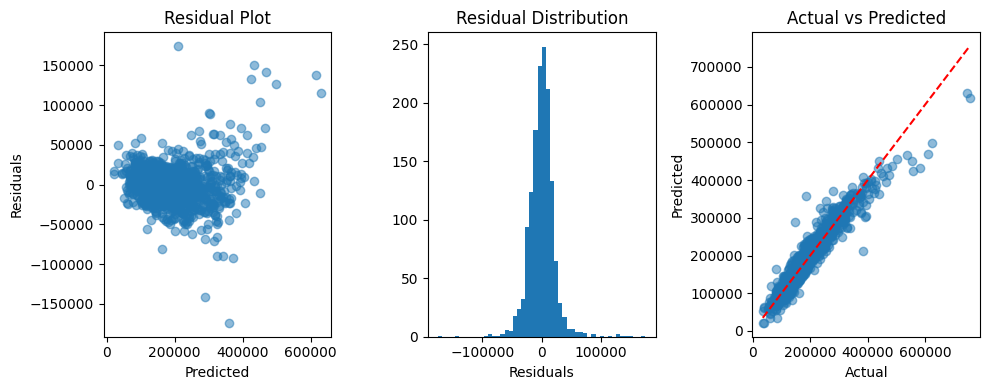

In [32]:
# Create a 1x3 grid of plots
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# 1. Residual Plot
ax[0].scatter(train_y_pred, residuals, alpha=0.5)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residual Plot')

# 2. Distribution of residuals
ax[1].hist(residuals, bins=50)
ax[1].set_xlabel('Residuals')
ax[1].set_title('Residual Distribution')

# 3. Actual vc Predict y
ax[2].scatter(train_y, train_y_pred, alpha=0.5)
ax[2].plot([train_y.min(), train_y.max()], [train_y.min(), train_y.max()], 'r--')
ax[2].set_xlabel('Actual')
ax[2].set_ylabel('Predicted')
ax[2].set_title('Actual vs Predicted')

# Adjust layout for spacing
plt.tight_layout()
plt.show()

**Residual Plot**
- Trục X: Giá dự đoán
- Trục Y: Sai số (Actual - Predicted)

--> Residuals phân bố khá đều quanh y=0, hông có pattern rõ ràng, có outliers

**Residual Distribution**
- Phân phối gần như chuẩn (bell-shaped)
- Tập trung quanh 0

**Actual vs Predicted**
- Trục X: Giá thật
- Trục Y: Giá dự đoán
- Đường đỏ chéo: dự đoán đúng (actual = predicted)

--> Hầu hết điểm nằm gần đường đỏ

### Evaluation conclusion and how to tune model

**Vì model có vẻ OVERFITTING, và các feature có tương quan cao (đã check lúc EDA), các features đều quan trọng nên dùng Ridge Regression**

(dùng Lasso nếu có rất nhiều features, nhưng có nhiều features không quan trọng, nó sẽ tự động feature selection)

- Linear Regression thông thường: Mục tiêu là Minimize RSS (Residual Sum of Squares)
- Ridge Regression (L2 Regularization): Mục tiêu là Minimize RSS + penalty (RSS + α × Σ(coefficient²))
- Lasso Regression (L1 Regularization): Mục tiêu là Minimize RSS + penalty (RSS + α × Σ|coefficient|)

## Tune model

In [ ]:
###

## Predict with test set

In [9]:
# Predict with test set
test_y_pred = model.predict(test_X_processed)

In [11]:
test_y_pred

array([118229.25927727, 156091.02562389, 176355.97223375, ...,
       172004.17020168, 111083.64182763, 225336.91370998], shape=(1459,))